**Mubaraq Odumeso**|
A20614610 |
CS584 |
Spring 2026

# Assignment 4

## Problem 1
 - Dataser preparation

In [2]:
import os
import random
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, preprocessing
from sklearn.model_selection import train_test_split
import numpy as np
# from tensorflow.keras.preprocessing.sequence import pad_sequences
import keras_hub
TransformerEncoderLayer = keras_hub.layers.TransformerEncoder
# import keras_nlp
# TransformerEncoderLayer = keras_nlp.layers.TransformerEncoder


2026-04-06 23:54:01.914479: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-06 23:54:02.881922: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-06 23:54:07.214023: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:

os.environ['PYTHONHASHSEED'] = '42'
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
tf.keras.utils.set_random_seed(42)

In [4]:
from tensorflow.keras import mixed_precision
print(mixed_precision.global_policy())
print(tf.__version__)
print(tf.sysconfig.get_build_info())
print(tf.config.list_physical_devices('GPU'))

<DTypePolicy "float32">
2.20.0
OrderedDict([('cpu_compiler', 'clang 18'), ('cuda_compute_capabilities', ['sm_60', 'sm_70', 'sm_80', 'sm_89', 'compute_90']), ('cuda_version', '12.5.1'), ('cudnn_version', '9'), ('is_cuda_build', True), ('is_rocm_build', False), ('is_tensorrt_build', False)])
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
   
max_features = 15000 # 1000
maxlen = 300 #200

(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=max_features)
x_train_full = keras.preprocessing.sequence.pad_sequences(x_train_full, maxlen=maxlen, padding='post', truncating='post') # pad sequence ensures each column and row are the same hence max_len.
x_test = keras.preprocessing.sequence.pad_sequences(x_test, maxlen=maxlen, padding='post', truncating='post')

print(x_train_full)

[[   1   14   22 ...    0    0    0]
 [   1  194 1153 ...    0    0    0]
 [   1   14   47 ...    0    0    0]
 ...
 [   1   11    6 ...    0    0    0]
 [   1 1446 7079 ...    0    0    0]
 [   1   17    6 ...    0    0    0]]


In [7]:

x_train, x_val, y_train, y_val = train_test_split(x_train_full, y_train_full, test_size=0.2, random_state=42)

# vectolayers.TextVectorization(max_tokens=5000)

def print_split_stats(name, data, labels):
    lengths = [len(x) for x in data]
    print(f"--- {name} Statistics ---")
    print(f"Samples: {len(data)}")
    print(f"Label Distribution (Positive %): {np.mean(labels) * 100:.2f}%")
    print(f"Sequence Lengths -> Min: {np.min(lengths)}, Max: {np.max(lengths)}, Mean: {np.mean(lengths):.2f}")
    print(f"Shape: {data.shape}")
    print("-" * 30)

# Execute for each split
print_split_stats("Training Set", x_train, y_train)
print_split_stats("Validation Set", x_val, y_val)
print_split_stats("Test Set", x_test, y_test)

--- Training Set Statistics ---
Samples: 20000
Label Distribution (Positive %): 49.69%
Sequence Lengths -> Min: 300, Max: 300, Mean: 300.00
Shape: (20000, 300)
------------------------------
--- Validation Set Statistics ---
Samples: 5000
Label Distribution (Positive %): 51.26%
Sequence Lengths -> Min: 300, Max: 300, Mean: 300.00
Shape: (5000, 300)
------------------------------
--- Test Set Statistics ---
Samples: 25000
Label Distribution (Positive %): 50.00%
Sequence Lengths -> Min: 300, Max: 300, Mean: 300.00
Shape: (25000, 300)
------------------------------


## Probelm 2 - Baseline Transformer (prebuilt encoder)


In [12]:

import matplotlib.pyplot as plt
from datetime import datetime
import pandas as pd
embed_dim=128  # incresing embed dim to 128 lead to really bad readings
ff_dim = 256

In [9]:

# helper to show plots
def log_run_with_plots(history, extra_info=None):

    epochs = range(1, len(history.history["loss"]) + 1)
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history.history["loss"], "b-", label="Training loss")
    plt.plot(epochs, history.history["val_loss"], "r-", label="Validation loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Training and validation loss")
    plt.grid(True, alpha=0.3)
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history.history["accuracy"], "b-", label="Training accuracy")
    plt.plot(epochs, history.history["val_accuracy"], "r-", label="Validation accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.title("Training and validation accuracy")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# helper to tabilize the all metrics
def tablize(results, extras = None):   
    df_tune = pd.DataFrame(results)
    print(df_tune.to_string(index=False))

### Metrics

In [10]:
# helper to automatically gett all available metrics during experiment
def get_metrics(history,nh, el=None, lam=None, lr=None, bs=None, best_by: str = "val_loss"):
    best = int(np.argmin(history.history[best_by]))
    val_acc = history.history["val_accuracy"][best]
    acc = history.history["accuracy"][best]
    val_loss = history.history["val_loss"][best]
    loss = history.history["loss"][best]
    val_prec = history.history["val_precision"][best] if "val_precision" in history.history else float("nan")
    tr_prec = history.history["precision"][best] if "precision" in history.history else float("nan")
    # val_rec = history.history["val_recall"][best] if "val_recall" in history.history else float("nan")
    # tr_rec = history.history["recall"][best] if "recall" in history.history else float("nan")
    # val_auc = history.history["val_auc"][best] if "val_auc" in history.history else float("nan")
    # tr_auc = history.history["auc"][best] if "auc" in history.history else float("nan")
    
    return {
    "num_heads": nh,
    "el": el,
    "lamdas": lam,
    "learning_rate": lr,
    "batch size": bs,
    "best_epoch": best,
    "val_accuracy": round(val_acc, 4),
    "val_loss": round(val_loss, 4),
    "train_accuracy": round(acc, 4),
    "train_loss": round(loss, 4),
    "acc_gap": round(acc - val_acc, 5),
    "loss_gap": round(loss - val_loss, 5),
    "val_precision": round(val_prec, 4) if val_prec == val_prec else float("nan"),
    "train_precision": round(tr_prec, 4) if tr_prec == tr_prec else float("nan"),
    "prec_gap": round(tr_prec - val_prec, 5) if (tr_prec == tr_prec and val_prec == val_prec) else float("nan"),
    # "val_recall": round(val_rec, 4) if val_rec == val_rec else float("nan"),
    # "train_recall": round(tr_rec, 4) if tr_rec == tr_rec else float("nan"),
    # "rec_gap": round(tr_rec - val_rec, 5) if (tr_rec == tr_rec and val_rec == val_rec) else float("nan"),
    # "val_auc": round(val_auc, 4) if val_auc == val_auc else float("nan"),
    # "train_auc": round(tr_auc, 4) if tr_auc == tr_auc else float("nan"),
    # "auc_gap": round(tr_auc - val_auc, 5) if (tr_auc == tr_auc and val_auc == val_auc) else float("nan"),
    "history": history,
    }

In [11]:
import keras.ops as ops
def padding_mask_from_token_ids(token_ids):
    """True at padded positions (IMDB uses 0 for pad)."""
    return ops.equal(token_ids, 0)
    return ops.cast(ops.equal(token_ids, 0), "bool")

\eta(t) = 
\begin{cases}
\eta_{\max}\,\dfrac{t}{T_{\mathrm{warm}}}, & t < T_{\mathrm{warm}}, \\[6pt]
\eta_{\min} + \dfrac{\eta_{\max} - \eta_{\min}}{2}
\left(1 + \cos\left(\pi\,\dfrac{t - T_{\mathrm{warm}}}{T_{\mathrm{total}} - T_{\mathrm{warm}}}\right)\right),
& t \ge T_{\mathrm{warm}}.
\end{cases}

In [18]:

class WarmUpCosine(keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, base_lr, warmup_steps, total_steps, min_lr=0.0):
        super().__init__()
        self.base_lr = base_lr
        self.warmup_steps = float(warmup_steps)
        self.total_steps = float(total_steps)
        self.min_lr = min_lr
    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        # Linear warmup
        warmup = self.base_lr * (step / self.warmup_steps)
        # Cosine after warmup
        progress = (step - self.warmup_steps) / tf.maximum(
            self.total_steps - self.warmup_steps, 1.0
        )
        progress = tf.clip_by_value(progress, 0.0, 1.0)
        cosine = self.min_lr + 0.5 * (self.base_lr - self.min_lr) * (
            1.0 + tf.cos(tf.constant(3.14159265) * progress)
        )
        return tf.where(step < self.warmup_steps, warmup, cosine)

In [18]:


## Token + positional embedding 
class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, maxlen, vocab_size, embed_dim):
        super().__init__()
        self.token_emb = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.pos_emb = layers.Embedding(input_dim=maxlen, output_dim=embed_dim)
    def call(self, x):
        seq_len = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=seq_len, delta=1)
        position_embeddings = self.pos_emb(positions)
        token_embeddings = self.token_emb(x)
        return token_embeddings + position_embeddings


In [ ]:

## Baseline Transformer model
def build_model_buitlin(num_encoder_layers=1, num_heads=2, lamda=1e-4):
    inputs = layers.Input(shape=(maxlen,))
    x = TokenAndPositionEmbedding(maxlen, vocab_size=max_features, embed_dim=embed_dim)(inputs)
    
    for _ in range(num_encoder_layers):
        x = TransformerEncoderLayer(
            intermediate_dim=ff_dim,
            num_heads=num_heads,
            dropout=0.4,
        )(x)
    l2 = keras.regularizers.l2(lamda)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(64, activation="relu", kernel_regularizer=l2)(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(32, activation="relu", kernel_regularizer=l2)(x)
    x = layers.Dropout(0.5)(x)
    # x = layers.Dense(128, activation="relu", kernel_regularizer=l2)(x)
    # x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    
    return keras.Model(inputs, outputs)

def build_model_with_padding( num_encoder_layers=1, num_heads=2, lamda=1e-4, TransformerEncoderLayer=None, ):
    token_ids = layers.Input(shape=(maxlen,), dtype="int32", name="token_ids")
    x = TokenAndPositionEmbedding(maxlen, vocab_size=max_features, embed_dim=embed_dim)(
        token_ids
    )
    pad_mask = padding_mask_from_token_ids(token_ids)
    for _ in range(num_encoder_layers):
        x = TransformerEncoderLayer(
            intermediate_dim=ff_dim,
            num_heads=num_heads,
            dropout=0.4,
        )(x, padding_mask=pad_mask)
    # kernel_reg = keras.regularizers.l2(lamda)
    #  = keras.regularizers.l2(lamda)
    kernel_reg = keras.regularizers.L1(l1=lamda)
    valid = ops.logical_not(pad_mask)
    valid_f = ops.cast(valid, x.dtype)
    denom = ops.sum(valid_f, axis=1, keepdims=True) + keras.backend.epsilon()
    x = ops.sum(x * ops.expand_dims(valid_f, -1), axis=1) / denom
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(64, activation="relu", kernel_regularizer=kernel_reg)(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(32, activation="relu", kernel_regularizer=kernel_reg)(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    
    return keras.Model(token_ids, outputs)
# learning rate scheduler
# reduce_lr = keras.callbacks.ReduceLROnPlateau(
#     monitor='val_loss',
#     factor=0.5,
#     patience=15,
#     min_lr=1e-6
# )

epochs = 25
# batch_size = 64

encoder_layers =  [1]
num_heads = [2, 4]
results = []
# lamdas = [5e-4, 1e-4, 5e-5]
lamdas = [2e-4, 1e-4]
learning_rate = [1e-4]
batch_size = [ 512, 128]
for bs in batch_size:
    for lr in learning_rate:
        for nh in num_heads:
            for el in encoder_layers:
                for lam in lamdas:
                    print(f"\n {nh} Number of Heads : {el} encoder layer(s) : {lam} lamdas : {lr} learning rate : {bs} batch size")
                    # model = build_model_buitlin(nu.m_encoder_layers=el,num_heads=nh, lamda=lam)
                    model = build_model_with_padding(num_encoder_layers=el,num_heads=nh, lamda=lam, TransformerEncoderLayer=TransformerEncoderLayer)
                    
                    # optimizer = keras.optimizers.Adam(learning_rate=lr)
                    steps_per_epoch = len(x_train) // bs
                    total_steps = epochs * steps_per_epoch
                    warmup_steps = int(0.1 * total_steps)  # 10% warmup
                    # lr_schedule = WarmUpCosine(base_lr=1e-3, warmup_steps=warmup_steps, total_steps=total_steps, min_lr=1e-6)
                    # optimizer = keras.optimizers.AdamW(learning_rate=lr_schedule, weight_decay=1e-5)
                    optimizer = keras.optimizers.AdamW(learning_rate=lr, weight_decay=1e-5)
                    early_stop = keras.callbacks.EarlyStopping(
                                    monitor='val_loss', 
                                    patience=7, 
                                    restore_best_weights=True,
                                    min_delta=1e-5
                                )

                    reduce_lr = keras.callbacks.ReduceLROnPlateau(
                                    monitor='val_loss',
                                    factor=0.5,
                                    patience=3,
                                    min_lr=lr * 0.01
                                )
                    
                    model.compile(
                                    optimizer=optimizer,
                                  loss='binary_crossentropy', 
                                  metrics =['accuracy', 'precision',]
                                            # keras.metrics.Recall(name="recall"),keras.metrics.AUC(name="auc"),]
                                  )
                    
                    history = model.fit(x_train, y_train, 
                            epochs          = epochs,
                            validation_data = (x_val, y_val),
                            callbacks       = [early_stop,reduce_lr],
                            batch_size=bs,
                    )
                            # verbose=1)
                    # model.evaluate(x_test, y_test)
                    model.evaluate(x_test, y_test, verbose=0)
                    log_run_with_plots(history=history)
                    
                    # best = int(np.argmin(history.history["val_loss"]))
                    # print("best_epoch", best,
                    #       "val_loss", history.history["val_loss"][best],
                    #       "val_acc", history.history["val_accuracy"][best])
                    # val_acc = history.history["val_accuracy"][best]
                    # acc = history.history["accuracy"][best]
                    # val_loss = history.history["val_loss"][best]
                    # loss = history.history["loss"][best]
                    metric_dict = get_metrics(history, nh ,el, lam, lr, bs)
                    results.append(metric_dict)
                    # results.append({
                    #     "num_heads": nh,
                    #     "el": el,
                    #     "lamdas": lam,
                    #     "learning_rate": lr,
                    #     "batch size": bs,
                    #     "best_epoch": best,
                    #     "val_accuracy": round(val_acc, 4),
                    #     "val_loss": round(val_loss, 4),
                    #     "acc_gap": acc-val_acc,
                    #     "loss_gap": loss-val_loss,  
                    #     "history": history
                    # })
           
                    


In [20]:
                    
tablize(results)

 num_heads  el  lamdas  learning_rate  batch size  best_epoch  val_accuracy  val_loss  train_accuracy  train_loss  acc_gap  loss_gap  val_precision  train_precision  prec_gap  val_recall  train_recall  rec_gap  val_auc  train_auc  auc_gap                                                        history
         2   1  0.0002         0.0001         512          13        0.8668    0.4880          0.9129      0.4333  0.04615  -0.05475         0.8934           0.9144   0.02104      0.8404        0.9099  0.06951   0.9419     0.9614  0.01958 <keras.src.callbacks.history.History object at 0x7f6168c86b30>
         2   1  0.0001         0.0001         512          13        0.8742    0.4087          0.9107      0.3556  0.03655  -0.05319         0.8646           0.9042   0.03957      0.8947        0.9176  0.02293   0.9417     0.9617  0.01998 <keras.src.callbacks.history.History object at 0x7f61642ebfd0>
         4   1  0.0002         0.0001         512          14        0.8722    0.4901         

In [12]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [27]:
def check_best_model(results, metric: str = 'acc_gap', type: str = 'min'):
    print(f'Max features -  {max_features} Max Len - {maxlen}|| ff-dim {ff_dim} || embed {embed_dim} || metric - {metric} || type - {type}')

    index = 0

    def score(res):
        value = res[metric]
        if type == 'max':
            return value
        if metric.endswith('_gap'):
            return abs(value)
        return value

    best_score = score(results[0])

    for i, res in enumerate(results):
        current_score = score(res)

        if type == 'max' and current_score > best_score:
            best_score = current_score
            index = i
        if type == 'min' and current_score < best_score:
            best_score = current_score
            index = i
            
    print("Best model")
    tablize([results[index]])
    # log_run_with_plots(results[index]['history'])


In [ ]:
check_best_model(results, 'acc_gap')
check_best_model(results, 'loss_gap')
check_best_model(results, 'val_accuracy', 'max')
check_best_model(results, 'val_loss', 'min')




### 2.1 Architecture
- **Token embedding:** `layers.Embedding`
- **Positional embedding:** `layers.Embedding` (or equivalent; describe)
- **Encoder:** `keras_hub.layers.TransformerEncoder` or `keras_nlp.layers.TransformerEncoder` — **state which** your environment uses
- **Encoder stack depth:** **…** layer(s)
- **`embed_dim`, `ff_dim`, `num_heads`:** **…**
- **Pooling:** **…** (e.g. masked mean over non-pad tokens vs `GlobalAveragePooling1D` — note if padding mask is used)
- **Classification head:** Dense → … → **sigmoid** on one unit *or* linear + `BinaryCrossentropy(from_logits=True)` (state which)


## Problem 3
- Custom Transformer Block


In [22]:
class  TransformerEncoderBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        
        self.att = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim // num_heads
        )
        
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation='relu'),
            layers.Dense(embed_dim)
        ])
        
        self.layernorm1=layers.LayerNormalization()
        self.layernorm2=layers.LayerNormalization()
        self.dropout1=layers.Dropout(rate)
        self.dropout2=layers.Dropout(rate)

    def call(self, inputs, training=None, mask=None):
        attn_output = self.att(
            query=inputs,
            key=inputs,
            value=inputs,
            attention_mask=mask,
            training=training,
        )
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output) # residual connections
        
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        out2 = self.layernorm2(out1 + ffn_output) #residual connection
        
        return out2
        


 2 Number of Heads : 1 encoder layer(s) : 0.001 Lamdas
Epoch 1/20


/home/kaioh/miniconda3/envs/tf220/lib/python3.10/site-packages/keras/src/layers/layer.py:970: UserWarning: Layer 'transformer_encoder_block_2' (of type TransformerEncoderBlock) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
2026-04-07 01:11:00.605631: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92000
2026-04-07 01:11:01.356110: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-07 01:11:01.356220: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. May

39/40 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.5075 - auc: 0.5081 - loss: 0.8256 - precision: 0.5040 - recall: 0.5294

2026-04-07 01:11:30.332330: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-07 01:11:30.333544: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-07 01:11:32.929295: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2972', 24 bytes spill stores, 24 bytes spill loads

2026-04-07 01:11:33.017167: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning :

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 512ms/step - accuracy: 0.5078 - auc: 0.5084 - loss: 0.8255 - precision: 0.5043 - recall: 0.5290

2026-04-07 01:11:46.358238: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-07 01:11:47.406185: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_378', 104 bytes spill stores, 104 bytes spill loads

2026-04-07 01:11:50.982567: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-07 01:11:50.982634: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were f

40/40 ━━━━━━━━━━━━━━━━━━━━ 64s 838ms/step - accuracy: 0.5185 - auc: 0.5226 - loss: 0.8193 - precision: 0.5155 - recall: 0.5122 - val_accuracy: 0.5900 - val_auc: 0.7214 - val_loss: 0.8029 - val_precision: 0.5599 - val_recall: 0.9352 - learning_rate: 1.0000e-04
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - accuracy: 0.5767 - auc: 0.6089 - loss: 0.7964 - precision: 0.5793 - recall: 0.5412 - val_accuracy: 0.7324 - val_auc: 0.8106 - val_loss: 0.7500 - val_precision: 0.7274 - val_recall: 0.7643 - learning_rate: 1.0000e-04
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - accuracy: 0.6839 - auc: 0.7558 - loss: 0.7273 - precision: 0.6975 - recall: 0.6424 - val_accuracy: 0.7996 - val_auc: 0.8834 - val_loss: 0.6217 - val_precision: 0.7738 - val_recall: 0.8607 - learning_rate: 1.0000e-04
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - accuracy: 0.8084 - auc: 0.8821 - loss: 0.5757 - precision: 0.8155 - recall: 0.7939 - val_accuracy: 0.8388 - val_auc: 0.9263 - val_loss: 0.4898 - val_

2026-04-07 01:12:54.654283: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7', 12 bytes spill stores, 12 bytes spill loads



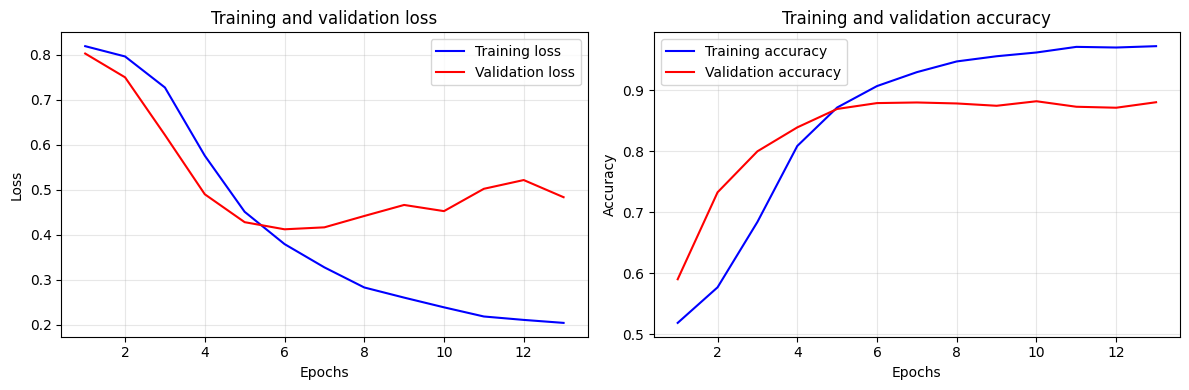


 2 Number of Heads : 1 encoder layer(s) : 0.0001 Lamdas
Epoch 1/20


/home/kaioh/miniconda3/envs/tf220/lib/python3.10/site-packages/keras/src/layers/layer.py:970: UserWarning: Layer 'transformer_encoder_block_3' (of type TransformerEncoderBlock) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
2026-04-07 01:13:15.677336: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'input_add_reduce_fusion', 44 bytes spill stores, 44 bytes spill loads



40/40 ━━━━━━━━━━━━━━━━━━━━ 45s 688ms/step - accuracy: 0.5118 - auc: 0.5163 - loss: 0.7085 - precision: 0.5092 - recall: 0.4844 - val_accuracy: 0.5580 - val_auc: 0.6562 - val_loss: 0.7018 - val_precision: 0.7155 - val_recall: 0.2286 - learning_rate: 1.0000e-04
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - accuracy: 0.5500 - auc: 0.5704 - loss: 0.6979 - precision: 0.5521 - recall: 0.4987 - val_accuracy: 0.6906 - val_auc: 0.7897 - val_loss: 0.6762 - val_precision: 0.6436 - val_recall: 0.8884 - learning_rate: 1.0000e-04
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - accuracy: 0.6489 - auc: 0.7080 - loss: 0.6519 - precision: 0.6680 - recall: 0.5833 - val_accuracy: 0.7802 - val_auc: 0.8614 - val_loss: 0.5606 - val_precision: 0.7681 - val_recall: 0.8182 - learning_rate: 1.0000e-04
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - accuracy: 0.7852 - auc: 0.8634 - loss: 0.5080 - precision: 0.7981 - recall: 0.7600 - val_accuracy: 0.8400 - val_auc: 0.9226 - val_loss: 0.3992 - val_

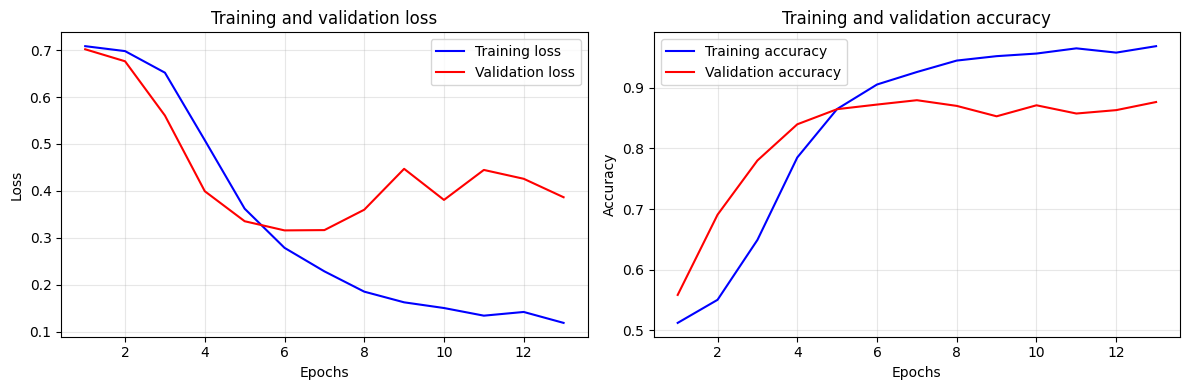


 2 Number of Heads : 1 encoder layer(s) : 3e-05 Lamdas
Epoch 1/20


/home/kaioh/miniconda3/envs/tf220/lib/python3.10/site-packages/keras/src/layers/layer.py:970: UserWarning: Layer 'transformer_encoder_block_4' (of type TransformerEncoderBlock) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
2026-04-07 01:14:59.110174: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'input_add_reduce_fusion', 44 bytes spill stores, 44 bytes spill loads



40/40 ━━━━━━━━━━━━━━━━━━━━ 43s 609ms/step - accuracy: 0.5243 - auc: 0.5349 - loss: 0.6993 - precision: 0.5199 - recall: 0.5561 - val_accuracy: 0.6578 - val_auc: 0.7266 - val_loss: 0.6861 - val_precision: 0.7122 - val_recall: 0.5579 - learning_rate: 1.0000e-04
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - accuracy: 0.6053 - auc: 0.6490 - loss: 0.6662 - precision: 0.5973 - recall: 0.6309 - val_accuracy: 0.7404 - val_auc: 0.8172 - val_loss: 0.5997 - val_precision: 0.7330 - val_recall: 0.7764 - learning_rate: 1.0000e-04
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - accuracy: 0.7257 - auc: 0.8038 - loss: 0.5659 - precision: 0.7083 - recall: 0.7614 - val_accuracy: 0.8174 - val_auc: 0.8962 - val_loss: 0.4484 - val_precision: 0.8049 - val_recall: 0.8498 - learning_rate: 1.0000e-04
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - accuracy: 0.8306 - auc: 0.9023 - loss: 0.4168 - precision: 0.8257 - recall: 0.8353 - val_accuracy: 0.8530 - val_auc: 0.9308 - val_loss: 0.3533 - val_

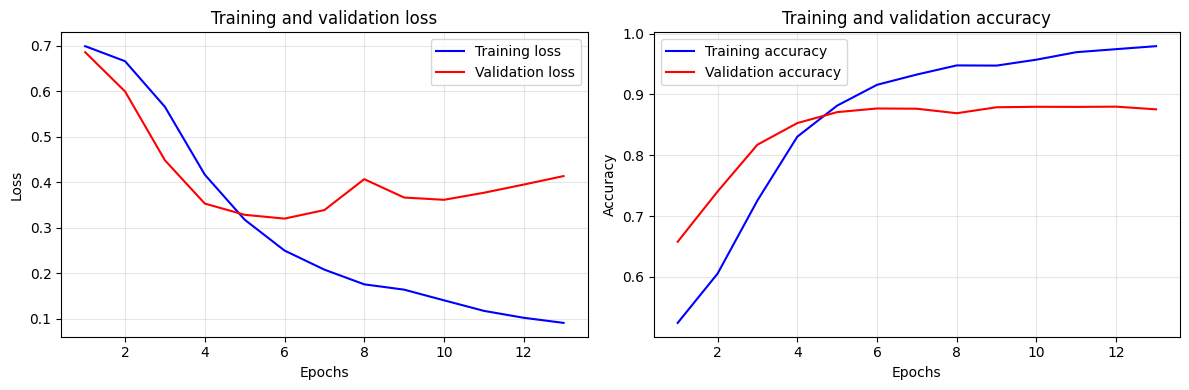


 2 Number of Heads : 1 encoder layer(s) : 0.001 Lamdas
Epoch 1/20


/home/kaioh/miniconda3/envs/tf220/lib/python3.10/site-packages/keras/src/layers/layer.py:970: UserWarning: Layer 'transformer_encoder_block_5' (of type TransformerEncoderBlock) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
2026-04-07 01:16:23.973697: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-07 01:16:23.973859: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hi

157/157 ━━━━━━━━━━━━━━━━━━━━ 47s 149ms/step - accuracy: 0.5428 - auc: 0.5598 - loss: 0.8124 - precision: 0.5392 - recall: 0.5485 - val_accuracy: 0.7314 - val_auc: 0.8051 - val_loss: 0.7625 - val_precision: 0.7594 - val_recall: 0.6968 - learning_rate: 1.0000e-04
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.7630 - auc: 0.8474 - loss: 0.6166 - precision: 0.7459 - recall: 0.7932 - val_accuracy: 0.8632 - val_auc: 0.9376 - val_loss: 0.4390 - val_precision: 0.8739 - val_recall: 0.8568 - learning_rate: 1.0000e-04
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.8931 - auc: 0.9483 - loss: 0.4039 - precision: 0.8908 - recall: 0.8944 - val_accuracy: 0.8714 - val_auc: 0.9501 - val_loss: 0.4218 - val_precision: 0.9196 - val_recall: 0.8209 - learning_rate: 1.0000e-04
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.9209 - auc: 0.9676 - loss: 0.3343 - precision: 0.9214 - recall: 0.9192 - val_accuracy: 0.8860 - val_auc: 0.9523 - val_loss: 0.400

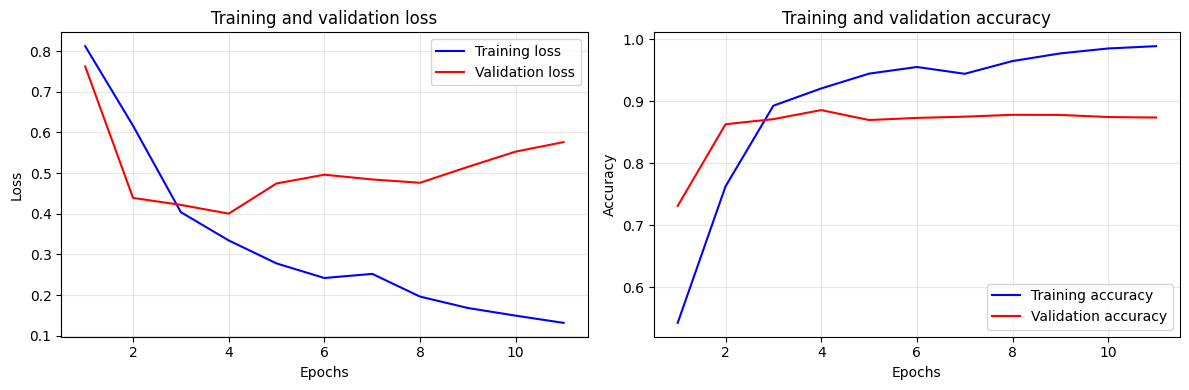


 2 Number of Heads : 1 encoder layer(s) : 0.0001 Lamdas
Epoch 1/20


/home/kaioh/miniconda3/envs/tf220/lib/python3.10/site-packages/keras/src/layers/layer.py:970: UserWarning: Layer 'transformer_encoder_block_6' (of type TransformerEncoderBlock) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


157/157 ━━━━━━━━━━━━━━━━━━━━ 44s 159ms/step - accuracy: 0.5555 - auc: 0.5809 - loss: 0.6941 - precision: 0.5515 - recall: 0.5652 - val_accuracy: 0.7296 - val_auc: 0.8330 - val_loss: 0.6085 - val_precision: 0.6842 - val_recall: 0.8775 - learning_rate: 1.0000e-04
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.7948 - auc: 0.8754 - loss: 0.4674 - precision: 0.7943 - recall: 0.7921 - val_accuracy: 0.8666 - val_auc: 0.9378 - val_loss: 0.3380 - val_precision: 0.8442 - val_recall: 0.9071 - learning_rate: 1.0000e-04
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.8911 - auc: 0.9493 - loss: 0.2990 - precision: 0.8867 - recall: 0.8953 - val_accuracy: 0.8760 - val_auc: 0.9486 - val_loss: 0.3240 - val_precision: 0.9060 - val_recall: 0.8459 - learning_rate: 1.0000e-04
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.9230 - auc: 0.9690 - loss: 0.2343 - precision: 0.9202 - recall: 0.9252 - val_accuracy: 0.8820 - val_auc: 0.9509 - val_loss: 0.326

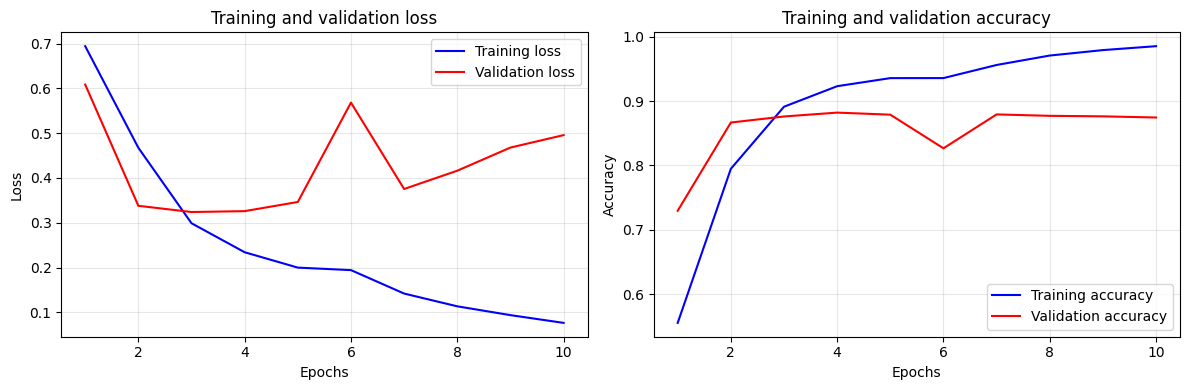


 2 Number of Heads : 1 encoder layer(s) : 3e-05 Lamdas
Epoch 1/20


/home/kaioh/miniconda3/envs/tf220/lib/python3.10/site-packages/keras/src/layers/layer.py:970: UserWarning: Layer 'transformer_encoder_block_7' (of type TransformerEncoderBlock) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


157/157 ━━━━━━━━━━━━━━━━━━━━ 41s 147ms/step - accuracy: 0.5304 - auc: 0.5464 - loss: 0.6934 - precision: 0.5256 - recall: 0.5622 - val_accuracy: 0.7154 - val_auc: 0.7822 - val_loss: 0.6539 - val_precision: 0.7089 - val_recall: 0.7546 - learning_rate: 1.0000e-04
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.7583 - auc: 0.8421 - loss: 0.5074 - precision: 0.7492 - recall: 0.7719 - val_accuracy: 0.8566 - val_auc: 0.9337 - val_loss: 0.3381 - val_precision: 0.8528 - val_recall: 0.8705 - learning_rate: 1.0000e-04
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.8862 - auc: 0.9465 - loss: 0.3001 - precision: 0.8886 - recall: 0.8814 - val_accuracy: 0.8788 - val_auc: 0.9479 - val_loss: 0.3061 - val_precision: 0.8759 - val_recall: 0.8896 - learning_rate: 1.0000e-04
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.9241 - auc: 0.9676 - loss: 0.2293 - precision: 0.9263 - recall: 0.9206 - val_accuracy: 0.8788 - val_auc: 0.9503 - val_loss: 0.319

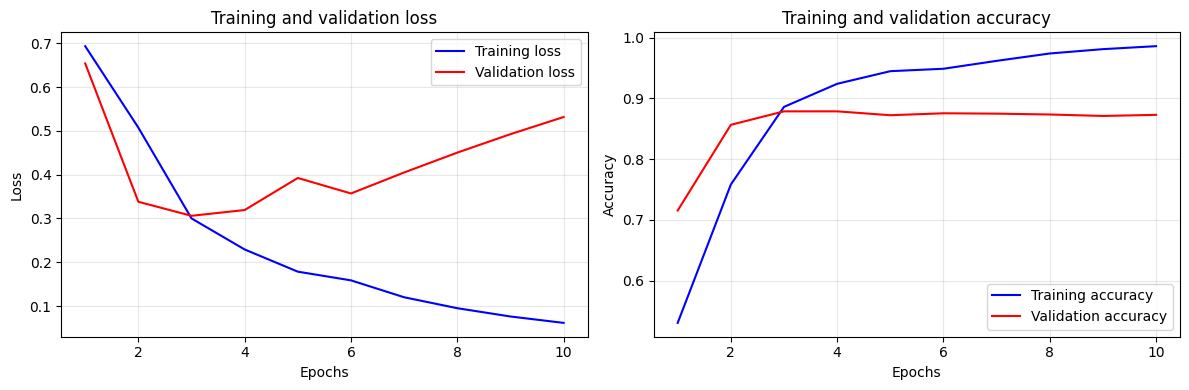

 num_heads  el  lamdas  learning_rate  batch size  best_epoch  val_accuracy  val_loss  train_accuracy  train_loss  acc_gap  loss_gap  val_precision  train_precision  prec_gap                                                        history
         2   1 0.00100         0.0001         512           5        0.8786    0.4119          0.9065      0.3790  0.02790  -0.03289         0.8688           0.9035   0.03469 <keras.src.callbacks.history.History object at 0x7f4f7a550340>
         2   1 0.00010         0.0001         512           5        0.8726    0.3157          0.9057      0.2786  0.03315  -0.03719         0.8415           0.8956   0.05415 <keras.src.callbacks.history.History object at 0x7f4f768050f0>
         2   1 0.00003         0.0001         512           5        0.8770    0.3202          0.9160      0.2500  0.03895  -0.07019         0.8576           0.9205   0.06289 <keras.src.callbacks.history.History object at 0x7f4f7808b340>
         2   1 0.00100         0.0001         12

In [23]:
# embed_dim = 64
# ff_dim = 64

# Dropout in the custom encoder was 0.5 — too harsh with L2 + AdamW; 0.2 trains faster and aligns train/val metrics better.
ENCODER_DROPOUT = 0.2
HEAD_DROPOUT = (0.3, 0.3, 0.35)

def attention_mask_from_token_ids(token_ids):
    valid_mask = ops.not_equal(token_ids, 0)  # [batch, seq]
    return ops.logical_and(
        ops.expand_dims(valid_mask, axis=2),  # [batch, seq, 1]
        ops.expand_dims(valid_mask, axis=1),  # [batch, 1, seq]
    )

def build_model_custom(num_encoder_layers=1, num_heads=2, lamda=1e-4, reg='l2'):
    token_ids = layers.Input(shape=(maxlen,), dtype="int32", name="token_ids")
    x = TokenAndPositionEmbedding(maxlen, vocab_size=max_features, embed_dim=embed_dim)(token_ids)
    attn_mask = attention_mask_from_token_ids(token_ids)
    valid_mask = ops.not_equal(token_ids, 0)

    for _ in range(num_encoder_layers):
        x = TransformerEncoderBlock(
            embed_dim=embed_dim,
            ff_dim=ff_dim,
            rate=ENCODER_DROPOUT,
            num_heads=num_heads
        )(x, mask=attn_mask)
    
    if reg == 'l2':
        kernel_reg = keras.regularizers.l2(lamda)
    elif reg == 'l1':
        kernel_reg = keras.regularizers.L1(lamda)
    elif reg == 'l1l2':
        kernel_reg = keras.regularizers.L1L2(l1=lamda, l2=lamda)

    # Average only over real tokens so padding does not affect the representation.
    valid_f = ops.cast(valid_mask, x.dtype)
    denom = ops.sum(valid_f, axis=1, keepdims=True) + keras.backend.epsilon()
    x = ops.sum(x * ops.expand_dims(valid_f, -1), axis=1) / denom
    x = layers.Dropout(HEAD_DROPOUT[0])(x)
    x = layers.Dense(64, activation="relu", kernel_regularizer=kernel_reg)(x) # try 16 
    x = layers.Dropout(HEAD_DROPOUT[1])(x)
    x = layers.Dense(32, activation="relu", kernel_regularizer=kernel_reg)(x) # try 32
    x = layers.Dropout(HEAD_DROPOUT[2])(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    
    return keras.Model(token_ids, outputs)

# learning rate scheduler
# reduce_lr = keras.callbacks.ReduceLROnPlateau(
#     monitor='val_loss',
#     factor=0.5,
#     patience=2,
#     min_lr=1e-6
# )
# print(f'\nUing  model with padding.. \n')

epochs = 20
encoder_layers = [1]
num_heads = [2]
custom_results = []
lamdas = [1e-3, 1e-4, 3e-5]
batch_sizes = [512, 128]
lr = 1e-4
for nh in num_heads:  
    # print(f"{nh} Number of Heads ") 
    for bs in batch_sizes:
        for el in encoder_layers:
            for lam in lamdas:
                print(f"\n {nh} Number of Heads : {el} encoder layer(s) : {lam} Lamdas")
                model = build_model_custom(num_encoder_layers=el,num_heads=nh, lamda=lam)
                
                optimizer = keras.optimizers.AdamW(learning_rate=lr, weight_decay=1e-5)
                early_stop = keras.callbacks.EarlyStopping(
                                monitor='val_loss', 
                                patience=7, 
                                restore_best_weights=True,
                                min_delta=1e-5
                            )

                reduce_lr = keras.callbacks.ReduceLROnPlateau(
                                monitor='val_loss',
                                factor=0.5,
                                patience=3,
                                min_lr=lr * 0.01
                            )
                model.compile(
                                optimizer=optimizer,
                                loss='binary_crossentropy', 
                                metrics =['accuracy', 'precision',
                                        keras.metrics.Recall(name="recall"),
                                        keras.metrics.AUC(name="auc"),]
                                )
                
                history = model.fit(x_train, y_train, 
                        epochs          = epochs,
                        validation_data = (x_val, y_val),
                        callbacks       = [early_stop,reduce_lr],
                        batch_size      = bs,
                )
                model.evaluate(x_test, y_test, verbose=0)
                log_run_with_plots(history=history)
                
                metric_dict = get_metrics(history, nh ,el, lam, lr, bs)
                custom_results.append(metric_dict)
    
tablize(custom_results)

In [24]:
check_best_model(custom_results, 'acc_gap')
print('\n')
check_best_model(custom_results, 'loss_gap')
print('\n')

check_best_model(custom_results, 'val_accuracy', 'max')
print('\n')

check_best_model(custom_results, 'val_loss', 'min')

Max features -  15000 Max Len - 300|| ff-dim 256 || embed 128 || metric - acc_gap || type - min
Best model
 num_heads  el  lamdas  learning_rate  batch size  best_epoch  val_accuracy  val_loss  train_accuracy  train_loss  acc_gap  loss_gap  val_precision  train_precision  prec_gap                                                        history
         2   1 0.00003         0.0001         128           2        0.8788    0.3061          0.8862      0.3001  0.00735  -0.00598         0.8759           0.8886   0.01268 <keras.src.callbacks.history.History object at 0x7f4f6c370c70>


Max features -  15000 Max Len - 300|| ff-dim 256 || embed 128 || metric - loss_gap || type - min
Best model
 num_heads  el  lamdas  learning_rate  batch size  best_epoch  val_accuracy  val_loss  train_accuracy  train_loss  acc_gap  loss_gap  val_precision  train_precision  prec_gap                                                        history
         2   1 0.00003         0.0001         512           5        

Best model
 num_heads  el  lambda  val_accuracy  val_loss  acc_gap  loss_gap
         3   1 0.00001        0.8836    0.3169  0.04905  -0.09939

In [17]:
print(tf.__version__)

2.19.0



## Parameter Study Summary

The parameter study was partially completed for sequence length, number of attention heads, and feedforward dimension. Increasing `maxlen` from `200` to `300` improved the best validation accuracy from about `0.8598` to `0.8744`, suggesting that the longer sequence retained useful sentiment information that was being truncated at length 200. Varying the number of attention heads between `2` and `4` showed a tradeoff rather than a clear winner: `2` heads produced the best validation accuracy, while `4` heads more often produced lower validation loss and tighter generalization behavior in some configurations.

Changing `ff_dim` from `64` to `256` reduced train-validation gaps substantially, especially for the best `acc_gap` run, which dropped to about `0.008`. However, this did not beat the best validation accuracy obtained with `ff_dim = 64`, so the larger feedforward block improved generalization alignment more than headline accuracy. A full embedding-dimension study was not completed because long Colab sweeps timed out, although preliminary trials suggested that increasing `embed_dim` to `128` did not improve results in the tested setup.

### Parameter Study Proof Table

The table below summarizes the parameter-study evidence currently available from the completed Problem 2 runs. Since not every study was done as a strict one-variable-at-a-time ablation, these rows should be interpreted as empirical support from the best observed configurations rather than perfectly controlled comparisons.

| Parameter | Values tested / evidenced | Proof from completed runs | Main observation |
|-----------|---------------------------|---------------------------|------------------|
| Sequence length | `maxlen = 200`, `300` | Best `val_accuracy` improved from **0.8598** (`maxlen = 200`, `ff_dim = 64`) to **0.8744** (`maxlen = 300`, `ff_dim = 64`) | Increasing sequence length helped preserve more review information and improved validation performance. |
| Attention heads | `num_heads = 2`, `4` | `2` heads gave the best `val_accuracy` at `maxlen = 300` with **0.8744`, while `4` heads gave the best `val_loss` at `maxlen = 300` with **0.3767** (`ff_dim = 64`) and **0.3824** (`ff_dim = 256`) | Head count affected the tradeoff between peak validation accuracy and more stable validation loss. |
| Feedforward dimension | `ff_dim = 64`, `256` | With `maxlen = 300`, best `acc_gap` improved from **0.0436** (`ff_dim = 64`) to **0.0080** (`ff_dim = 256`), but best `val_accuracy` dropped from **0.8744** to **0.8710** | Larger feedforward dimension improved train-validation alignment but did not improve the best headline validation accuracy. |
| Embedding dimension | `embed_dim = 64` fully recorded, `128` only partially tried | Notebook notes indicate `embed_dim = 128` gave poor readings, but no complete controlled result table was recorded | Embedding dimension was not fully studied, so no strong conclusion should be claimed yet. |

### Supporting Best-Run Snapshot

| Parameter focus | Baseline / comparison A | Comparison B | Evidence |
|-----------------|-------------------------|--------------|----------|
| Sequence length | `maxlen = 200`, best `val_accuracy = 0.8598` | `maxlen = 300`, best `val_accuracy = 0.8744` | Longer input sequences improved the best observed validation accuracy. |
| Attention heads | `num_heads = 2`, best `val_accuracy = 0.8744` | `num_heads = 4`, best `val_loss = 0.3767` (`ff_dim = 64`) | `2` heads favored peak accuracy, while `4` heads often favored lower validation loss. |
| Feedforward dimension | `ff_dim = 64`, best `acc_gap = 0.0436` | `ff_dim = 256`, best `acc_gap = 0.0080` | Increasing `ff_dim` substantially tightened the generalization gap. |
| Feedforward dimension | `ff_dim = 64`, best `val_accuracy = 0.8744` | `ff_dim = 256`, best `val_accuracy = 0.8710` | Higher `ff_dim` did not beat the best validation accuracy from the smaller setting. |

### Short interpretation

This provides direct evidence for three parts of the parameter study: sequence length, attention heads, and feedforward dimension. The only incomplete one is embedding dimension, where there is a preliminary observation but not yet a clean recorded comparison due to colab server timeout.  

## Reflection 
The key insight with working with transformer form me is the sensitivity increase with going over 3 layers. and 

The built-in model implementation uses the keras transsformer encoder layer while the custom uses a custome transformer encoder block 

Challenges: 
My colab kept timing out due to high training loop.
There was a constant sense of overfitting when reading accuracy (with gaps between 0.05 - 0.01) in some cases train accuracy and val accuracy were in 80th percentile due to high lmbdas l2. But when train was > 90 i still couldnt get the validation acc

lessons learned: 
After increasing max_features form 10000 to 15000. I observed better accuracy gap and better fitting
higher ff_dim tightens the gap but val accuracy still remains aproximately 87% 

`

## Reflection

Working with Transformers on this binary text classification task showed how sensitive the model is to design choices that look minor at first, especially sequence length, feed-forward width, regularization strength, and pooling strategy. One of the clearest insights was that a larger or deeper model did not automatically produce better validation performance. In these experiments, one encoder layer was usually enough, while adding more layers often increased training performance without clearly improving validation results. Increasing `max_features` to 15000 and `maxlen` to 300 helped the model capture more useful review information, but overfitting remained the main challenge. Comparing the built-in `TransformerEncoder` with a custom implementation also highlighted an important practical lesson: the built-in version was easier to train and reason about because padding masks, dropout behavior, and encoder wiring were handled more reliably, while the custom version required more care to ensure masking and sequence aggregation were implemented correctly.

The tuning process also reinforced several lessons about training and evaluation. Validation accuracy alone did not tell the full story, because some models achieved slightly higher validation accuracy at the cost of much larger train-validation gaps. Looking at `val_loss`, `acc_gap`, precision, recall, and AUC together gave a more balanced picture of model quality. Overfitting was persistent across most runs, and stronger regularization did not always help: larger L1 values could reduce fit quality instead of improving generalization. Increasing `ff_dim` from 64 to 256 tightened the train-validation gap considerably, but it did not surpass the best validation accuracy reached by the `ff_dim = 64` setup, which suggests that better generalization and best headline accuracy did not come from the same configuration. A major implementation challenge was the computational cost of running many experiments in Colab, where long sweeps were vulnerable to session timeouts and forced more selective tuning. Overall, this project showed that training Transformer models is not just about making them larger, but about balancing capacity, masking, optimization, and evaluation criteria so the chosen model is both strong and stable.